<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week2%ED%85%8D%EC%8A%A4%ED%8A%B8%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 토픽 모델링- 20 뉴스그룹

문서 집합에 숨어 있는 주제를 찾아내는 것

*  LDA(Latent Dirichlet Allocation) 기법

 fetch_20newsgroups( ) API는 categories 파라미터를 통해 필요한
주제만 필터링해 추출하고 추출된 텍스트를 Count 기반으로 벡터화 변환

In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cats=['rec.motorcycles','rec.sport.baseball','comp.graphics','comp.windows.x',
      'talk.politics.mideast','soc.religion.christian','sci.electronics','sci.med']
news_df=fetch_20newsgroups(subset='all',remove=('headers','footers','quotes'),
                           categories=cats,random_state=0)
count_vect=CountVectorizer(max_df=0.95,max_features=1000,min_df=2,stop_words='english',
                           ngram_range=(1,2))

feat_vect=count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:',feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


In [4]:
lda=LatentDirichletAllocation(n_components=8,random_state=0)
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

In [5]:
print(lda.components_.shape)
lda.components_

(8, 1000)


array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

In [7]:
def display_topics(model,feature_names,no_top_words):
  for topic_index, topic in enumerate(model.components_):
    print('Topic #',topic_index)

    topic_word_indexes=topic.argsort()[::-1]
    top_indexes=topic_word_indexes[:no_top_words]
    feature_concat=' '.join([feature_names[i] for i in top_indexes])
    print(feature_concat)

feature_names=count_vect.get_feature_names_out()
display_topics(lda,feature_names,15)


Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


## 문서 유사도

### 문서 유사도 측정 방법 - 코사인 유사도
코사인 유사도는 두 벡터 사이의 사잇각을 구해서 얼마나 유사한지 수치로 적
용한 것

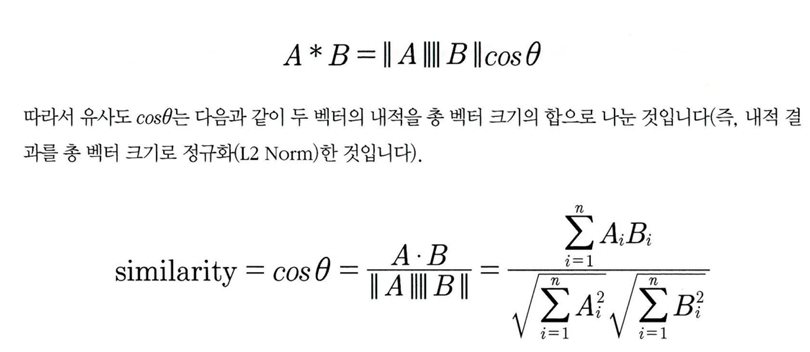

In [8]:
import numpy as np

def cos_similarity(v1,v2):
  dot_product=np.dot(v1,v2)
  l2_norm=(np.sqrt(sum(np.square(v1)))*(np.sqrt(sum(np.square(v2)))))
  similarity=dot_product/l2_norm
  return similarity

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_list=['if you take the blue pill, the story ends',
          'if you take the red pill, you stay in Wonderland',
          'if you take the red pill, I show you how deep the rabbit hole goes']
tifid_vect_simple=TfidfVectorizer()
feature_vect_simple=tifid_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


In [15]:
feature_vect_dense=feature_vect_simple.todense()
vect1=np.array(feature_vect_dense[0]).reshape(-1,)
vect2=np.array(feature_vect_dense[1]).reshape(-1,)

similarity_simple=cos_similarity(vect1,vect2)
print('문장 1, 문장 2 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 2 Cosine 유사도: 0.402


In [16]:
feature_vect_dense=feature_vect_simple.todense()
vect1=np.array(feature_vect_dense[0]).reshape(-1,)
vect3=np.array(feature_vect_dense[2]).reshape(-1,)

similarity_simple=cos_similarity(vect1,vect3)
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

feature_vect_dense=feature_vect_simple.todense()
vect3=np.array(feature_vect_dense[2]).reshape(-1,)
vect2=np.array(feature_vect_dense[1]).reshape(-1,)

similarity_simple=cos_similarity(vect2,vect3)
print('문장 2, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도: 0.456


사이킷런은 코사인 유사도를 측정하기 위해 sklearn. metrics. pairwise. cosine_similarity API를 제
공

 cosine_similarity() 함
수는 두 개의 입력 파라미터를 받습니다. 첫 번째 파라미터는 비교 기준이 되는 문서의 피처 행렬, 두
번째 파라미터는 비교되는 문서의 피처 행렬입니다.

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair=cosine_similarity(feature_vect_simple[0],feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair=cosine_similarity(feature_vect_simple[0],feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [21]:
similarity_simple_pair=cosine_similarity(feature_vect_simple,feature_vect_simple)
print(similarity_simple_pair)
print('shape',similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape (3, 3)


### Opinion Review 데이터 세트를 이용한 문서 유사도 측정

In [22]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from google.colab import drive

# 드라이브 마운트 (필요할 경우)
drive.mount('/content/drive')

# 필수 NLTK 데이터 다운로드
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

def LemNormalize(text):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in word_tokenize(text)]

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [33]:
import pandas as pd
import glob, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

path=r'/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/topics'
all_files = sorted(glob.glob(os.path.join(path,"*.data")))
filename_list=[]
opinion_text=[]

for file_ in all_files:
  df=pd.read_table(file_,index_col=None,header=0,encoding='latin1')
  filename_=file_.split('/')[-1]
  filename=filename_.split('.')[0]

  filename_list.append(filename)
  opinion_text.append(df.to_string())

document_df=pd.DataFrame({'filename':filename_list,'opinion_text':opinion_text})
document_df.head()

tfidf_vect=TfidfVectorizer(tokenizer=LemNormalize,stop_words='english',ngram_range=(1,2),
                           min_df=0.05,max_df=0.85)
feature_vect=tfidf_vect.fit_transform(document_df['opinion_text'])

km_cluster=KMeans(n_clusters=3,max_iter=10000,random_state=0)
km_cluster.fit(feature_vect)
cluster_label=km_cluster.labels_
cluster_centers=km_cluster.cluster_centers_
document_df['cluster_label']=cluster_label


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


호텔을 주제로 군집화된 데이터를 먼저 추출하고 이 데이터에 해당하는
TfidfVectorizer의 데이터를 추출

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

hotel_indexes=document_df[document_df['cluster_label']==1].index
print('호텔로 클러스터링 된 문서들의 DataFrame Index:', hotel_indexes)

comparison_docname=document_df.iloc[hotel_indexes[0]]['filename']
print('####비교 기준 문서명',comparison_docname,'와 타 문서 유사도####')

similarity_pair=cosine_similarity(feature_vect[hotel_indexes[0]],feature_vect[hotel_indexes])
print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame Index: Index([1, 6, 7, 13, 14, 15, 17, 18, 20, 21, 24, 28, 30, 31, 32, 37, 38, 39, 40,
       45, 46],
      dtype='int64')
####비교 기준 문서명 bathroom_bestwestern_hotel_sfo 와 타 문서 유사도####
[[1.         0.03657571 0.04457442 0.04319978 0.05169433 0.06298108
  0.02074346 0.01572569 0.0606086  0.06351759 0.03664464 0.11646047
  0.51043576 0.38344746 0.32670988 0.01741348 0.11675962 0.13603262
  0.14014484 0.09839206 0.07347054]]


시각화

가장 유사도가 큰 파일명 및 유사도:
 filename      room_holiday_inn_london
similarity                   0.510436
Name: 30, dtype: object


Text(0.5, 1.0, 'bathroom_bestwestern_hotel_sfo')

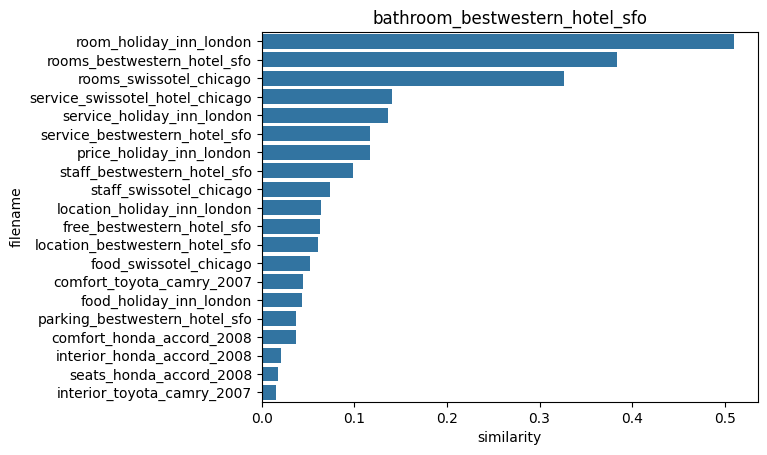

In [39]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sorted_index=similarity_pair.argsort()[:,::-1]
sorted_index=sorted_index[:,1:]

hotel_sorted_indexes=hotel_indexes[sorted_index.reshape(-1)]
hotel_1_sim_value=np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value=hotel_1_sim_value[1:]

hotel_1_sim_df=pd.DataFrame()
hotel_1_sim_df['filename']=document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity']=hotel_1_sim_value
print('가장 유사도가 큰 파일명 및 유사도:\n',hotel_1_sim_df.iloc[0,:])

sns.barplot(x='similarity',y='filename',data=hotel_1_sim_df)
plt.title(comparison_docname)

## 09 한글 텍스트 처리- 네이버 영화 평점 감성 분석

* KoNLPy: 파이썬의 대표적인 한글 형태소 패키지

형태소 분석(Morphological analysis)이란 말뭉치를 이
러한 형태소 어근 단위로 쪼개고 각 형태소에 품사 태깅(POS tagging)을 부착하는 작업

In [40]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/universe/o/openjdk-8/openjdk-8-jre-headless_8u472-ga-1%7e22.04_amd64.deb  404  Not Found [IP: 91.189.92.23 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/universe/o/openjdk-8/openjdk-8-jdk-headless_8u472-ga-1%7e22.04_amd64.deb  404  Not Found [IP: 91.189.92.23 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?


In [41]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

In [42]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 22.2 MB/s eta 0:00:00


In [45]:
import pandas as pd

train_df=pd.read_csv('ratings_train.txt',sep='\t',encoding='utf-8')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [46]:
train_df['label'].value_counts()

,count
label,
0,75173
1,74827


 train_df의 경우 리
뷰 텍스트를 가지는 ‘document’ 칼럼에 Null이 일부 존재하므로 이 값은 공백으로 변환합니다. 문자가
아닌 숫자의 경우 단어적인 의미로 부족하므로 파이썬의 정규 표현식 모듈인 re를 이용해 이 역시 공백
으로 변환

In [47]:
import re

train_df=train_df.fillna(' ')
train_df['document']=train_df['document'].apply(lambda x:re.sub(r"\d+"," ",x))

test_df=pd.read_csv('ratings_test.txt',sep='\t',encoding='utf-8')
test_df=test_df.fillna(' ')
test_df['document']=test_df['document'].apply(lambda x:re.sub(r"\d+"," ",x))

train_df.drop('id',axis=1,inplace=True)
test_df.drop('id',axis=1,inplace=True)

TF-IDF 방식으로 단어를 벡터화할 텐데, 먼저 각 문장을 한글 형태소 분석을 통해 형태소
단어로 토큰화하겠습니다. 한글 형태소 엔진은 SNS 분석에 적합한 Twitter 클래스를 이용

In [48]:
from konlpy.tag import Twitter

twitter =Twitter()
def tw_tokenizer(text):
  tokens_ko=twitter.morphs(text)
  return tokens_ko

/usr/local/lib/python3.12/dist-packages/konlpy/tag/_okt.py:17: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

tfidf_vect=TfidfVectorizer(tokenizer=tw_tokenizer,ngram_range=(1,2),min_df=3,max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train=tfidf_vect.transform(train_df['document'])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [53]:
lg_clf=LogisticRegression(random_state=0,solver='liblinear')

params={'C':[1,3.5,4.5,5.5,10]}
grid_cv=GridSearchCV(lg_clf,param_grid=params,cv=3,scoring='accuracy',verbose=1)
grid_cv.fit(tfidf_matrix_train,train_df['label'])
print(grid_cv.best_params_,round(grid_cv.best_score_,4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8593


In [54]:
from sklearn.metrics import accuracy_score

tifidf_matrix_test=tfidf_vect.transform(test_df['document'])

best_estimator=grid_cv.best_estimator_
preds=best_estimator.predict(tifidf_matrix_test)

print('Logistic Regression 정확도: ',accuracy_score(test_df['label'],preds))

Logistic Regression 정확도:  0.86172
